# Xception para clasificacion de aves CUB-200-2011


## 1. Importar librerias y configurar parametros


In [ ]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.xception import Xception, preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
DATASET_NAME = "caltech_birds2011"
IMG_SIZE = 299
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 5e-4
DROPOUT_RATE = 0.20


MODO = "augmentation"  # "transfer" | "augmentation" | "finetuning"
USAR_AUGMENTATION = MODO in ("augmentation", "finetuning")
HACER_FINETUNING = MODO == "finetuning"

# Hiperparametros de la fase de fine-tuning (solo se usan si MODO == "finetuning").
FINETUNE_FREEZE_LAYERS = 80  # capas iniciales del base que quedan congeladas
FINETUNE_LR = 1e-5           # LR bajo para no desestabilizar los pesos preentrenados
FINETUNE_EPOCHS = 20         # epocas adicionales para la 2da fase

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

#Generacion de rutas para guardar los datasets, resultados y modelos
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "modelos" else Path.cwd()
TFDS_DATA_DIR = PROJECT_ROOT / "dataset"
RESULTS_DIR = PROJECT_ROOT / "resultados"
MODELS_DIR = PROJECT_ROOT / "modelos_guardados"

TFDS_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


print("Modo de experimento:", MODO)
print("Augmentation:", USAR_AUGMENTATION, "| Fine-tuning:", HACER_FINETUNING)
print("Dataset cache:", TFDS_DATA_DIR)

2026-06-29 20:08:14.584084: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-29 20:08:15.399732: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-29 20:08:19.668483: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Modo de experimento: transfer
Augmentation: False | Fine-tuning: False
Dataset cache: /home/felipe_r/proyectos/TP3-CNN/dataset


## 2. Cargar el dataset

Usamos splits directos de TFDS para evitar filtros manuales, indices y `steps_per_epoch`. El split oficial `train` se divide en entrenamiento y validacion; el split oficial `test` queda para evaluacion final.


In [2]:
TRAIN_SPLIT = "train[:80%]"
VAL_SPLIT = "train[80%:]"
TEST_SPLIT = "test"
print("Splits:", TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT)

(ds_train_raw, ds_val_raw, ds_test_raw), info = tfds.load(
    DATASET_NAME,
    split=[TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT],
    as_supervised=True,
    with_info=True,
    shuffle_files=False,
    data_dir=str(TFDS_DATA_DIR),
)

num_classes = info.features["label"].num_classes
class_names = info.features["label"].names

print(f"Clases: {num_classes}")
print(f"Train examples: {tf.data.experimental.cardinality(ds_train_raw).numpy()}")
print(f"Validation examples: {tf.data.experimental.cardinality(ds_val_raw).numpy()}")
print(f"Test examples: {tf.data.experimental.cardinality(ds_test_raw).numpy()}")


Splits: train[:80%] train[80%:] test


I0000 00:00:1782763708.247810   81078 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Clases: 200
Train examples: 4795
Validation examples: 1199
Test examples: 5794


## 3. Visualizar algunas imagenes del dataset


2026-06-29 20:08:32.084680: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2026-06-29 20:08:32.419782: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


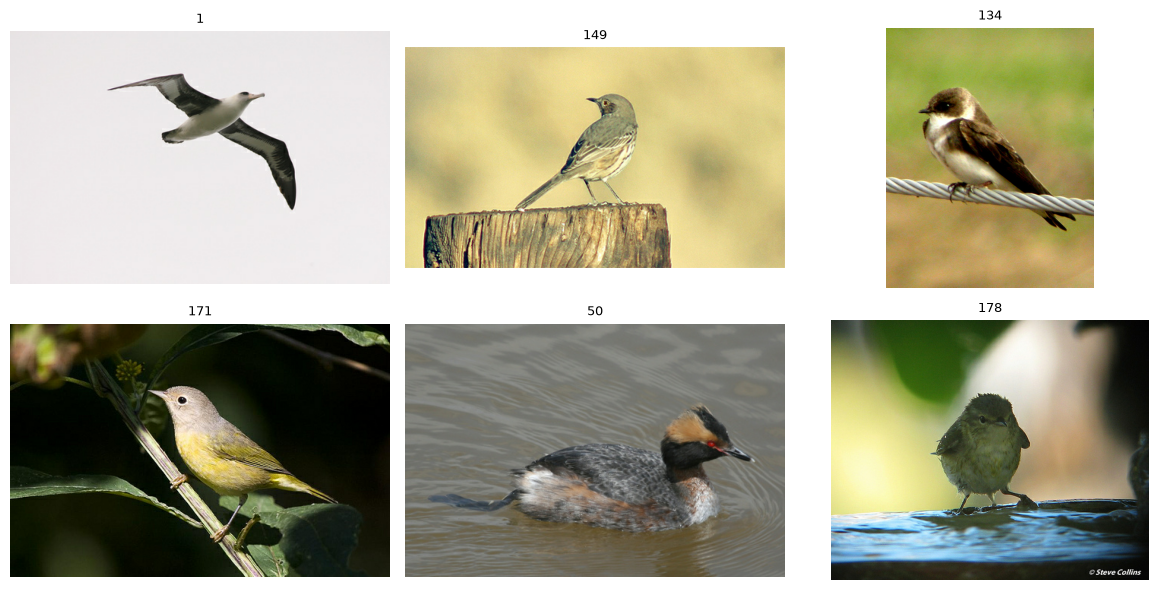

In [3]:
plt.figure(figsize=(12, 6))
for i, (image, label) in enumerate(ds_train_raw.take(6)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[int(label.numpy())], fontsize=9)
    plt.axis("off")
plt.tight_layout()


## 4. Funcion para Graficar entrenamiento y mostrar tabla de valores

In [4]:
def plot_training_history(history):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history_df["accuracy"], label="train")
    axes[0].plot(history_df["val_accuracy"], label="validation")
    axes[0].set_title("Accuracy (Precisión)")
    axes[0].set_xlabel("Epocas")
    axes[0].set_ylabel("Precisión")
    axes[0].legend()

    axes[1].plot(history_df["loss"], label="train")
    axes[1].plot(history_df["val_loss"], label="validation")
    axes[1].set_title("Función de Loss")
    axes[1].set_xlabel("Epocas")
    axes[1].set_ylabel("Error")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return history_df

## 5. Preprocesamiento del Dataset
CUB tiene imagenes de tamanos variables. Usamos `resize_with_pad` para llevarlas a `299x299` sin deformar la proporcion. Luego aplicamos `preprocess_input` de Xception.


In [5]:
AUTOTUNE = tf.data.AUTOTUNE


def preprocess_image(image, label):
    """
    Redimensiona una imagen del dataset al tamaño de entrada del modelo y prepara su etiqueta.

    La imagen se ajusta con padding para conservar la proporcion original, luego se convierte
    a float32 y se aplica el preprocesamiento especifico del modelo utilizado. La etiqueta
    se castea a entero para no usar One-Hot Encoding.

    Args:
        image: Tensor con la imagen original de CUB-200-2011.
        label: Indice entero de la clase.

    Returns:
        tuple: Imagen preprocesada y etiqueta entera.
    """

    image = tf.image.resize_with_pad(image, IMG_SIZE, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    label = tf.cast(label, tf.int32)
    return image, label


def prepare_dataset(dataset, training=False):
    """
    Aplica el preprocesamiento a todos los conjuntos del dataset. Si se indica entrenamiento, 
    mezcla los ejemplos antes de agruparlos en batches. 
    Prefetch prepara un batch y lo manda a entrenar, en paralelo prepara el siguiente Batch.

    Args:
        dataset: Dataset de TensorFlow con pares (image, label).
        training: Si es True, aplica shuffle para entrenamiento.

    Returns:
        tf.data.Dataset: Dataset listo para ser consumido por model.fit o model.evaluate.
    """

    dataset = dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    if training:
        dataset = dataset.shuffle(1024, seed=42, reshuffle_each_iteration=True)

    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = prepare_dataset(ds_train_raw, training=True)
val_ds = prepare_dataset(ds_val_raw)
test_ds = prepare_dataset(ds_test_raw)

for images, labels in train_ds.take(1):
    print("Batch imagenes:", images.shape)
    print("Batch labels:", labels.shape)
    print("Label dtype:", labels.dtype)


Batch imagenes: (16, 299, 299, 3)
Batch labels: (16,)
Label dtype: <dtype: 'int32'>


2026-06-29 20:08:54.425545: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 5.b Data augmentation

Para mejorar la generalizacion y reducir el overfitting aplicamos *data augmentation*: transformaciones aleatorias sobre las imagenes de entrenamiento. Las definimos como capas de Keras dentro del modelo, por lo que **solo se activan durante el entrenamiento** (`model.fit`) y quedan inactivas en validacion, evaluacion y prediccion.

- `RandomFlip("horizontal")`: refleja la imagen de izquierda a derecha. No usamos flip vertical porque un ave no aparece boca abajo.
- `RandomRotation(0.15)`: rota levemente la imagen.
- `RandomZoom(0.15)`: acerca o aleja levemente.

Usamos `fill_mode="reflect"` para que las rotaciones y el zoom no dejen bordes con relleno gris.

In [5]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15, fill_mode="reflect"),
        layers.RandomZoom(0.15, fill_mode="reflect"),
    ],
    name="data_augmentation",
)

In [ ]:
# Visualizamos varias versiones aumentadas de una misma imagen de entrenamiento.
for sample_image, _ in ds_train_raw.take(1):
    sample = tf.image.resize_with_pad(tf.cast(sample_image, tf.float32), IMG_SIZE, IMG_SIZE)

plt.figure(figsize=(12, 6))
for i in range(6):
    augmented = data_augmentation(tf.expand_dims(sample, 0), training=True)
    plt.subplot(2, 3, i + 1)
    plt.imshow(np.clip(augmented[0].numpy(), 0, 255).astype("uint8"))
    plt.axis("off")
plt.suptitle("Ejemplos de data augmentation")
plt.tight_layout()
plt.show()

## 6. Definir el modelo base


Para iniciar con el transfer learning lo que hacemos es congelar todas las capas del Modelo preentrenado con el dataset de Imagenet, no incluimos su capa clasificadora. Agregamos nuestras capas finales propias que sirven para resolver el problema de clasificación que estamos abordando

In [6]:
base_model = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# La data augmentation se enchufa solo en los modos que la usan (ver MODO).
if USAR_AUGMENTATION:
    x = data_augmentation(inputs)
else:
    x = inputs
# Ponemos training=False en base_model para mantener las capas de Batch Normalization en modo inferencia.
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(DROPOUT_RATE)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs, name=f"Xception_{MODO}")
model.summary()

Model: "Xception_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       409,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,271,280 (81.14 MB)

 Trainable params: 409,800 (1.56 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

## 7. Compilar el modelo


Establecemos el `Algoritmo de Optimización`, la `Función de Coste` y las `metricas`. 

Epoch 1/30


2026-06-29 20:09:35.605886: I external/local_xla/xla/service/service.cc:163] XLA service 0x79f71c002900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-29 20:09:35.605926: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-06-29 20:09:35.732937: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-29 20:09:37.594227: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92302
2026-06-29 20:09:46.961985: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.33GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-06-29 20:09:51.46470

299/300 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.0981 - loss: 4.7419

2026-06-29 20:10:49.215724: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.20GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-06-29 20:10:52.761055: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-29 20:10:52.934188: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-29 20:10:54.763975: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate

300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.0985 - loss: 4.7398

2026-06-29 20:11:19.536338: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.26GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-06-29 20:11:21.113703: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.25GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-06-29 20:11:24.249662: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-29 20:11:24.439521: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has s

300/300 ━━━━━━━━━━━━━━━━━━━━ 126s 287ms/step - accuracy: 0.1971 - loss: 4.1188 - val_accuracy: 0.3445 - val_loss: 3.1932
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 47s 143ms/step - accuracy: 0.5128 - loss: 2.6014 - val_accuracy: 0.4704 - val_loss: 2.5217
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 43s 140ms/step - accuracy: 0.6204 - loss: 2.0134 - val_accuracy: 0.5188 - val_loss: 2.1878
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 43s 140ms/step - accuracy: 0.6863 - loss: 1.6679 - val_accuracy: 0.5413 - val_loss: 2.0041
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 46s 150ms/step - accuracy: 0.7278 - loss: 1.4322 - val_accuracy: 0.5555 - val_loss: 1.8643
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 44s 143ms/step - accuracy: 0.7620 - loss: 1.2650 - val_accuracy: 0.5605 - val_loss: 1.7965
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.7892 - loss: 1.1350 - val_accuracy: 0.5730 - val_loss: 1.7173
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.7996 - loss: 1.0341 - va

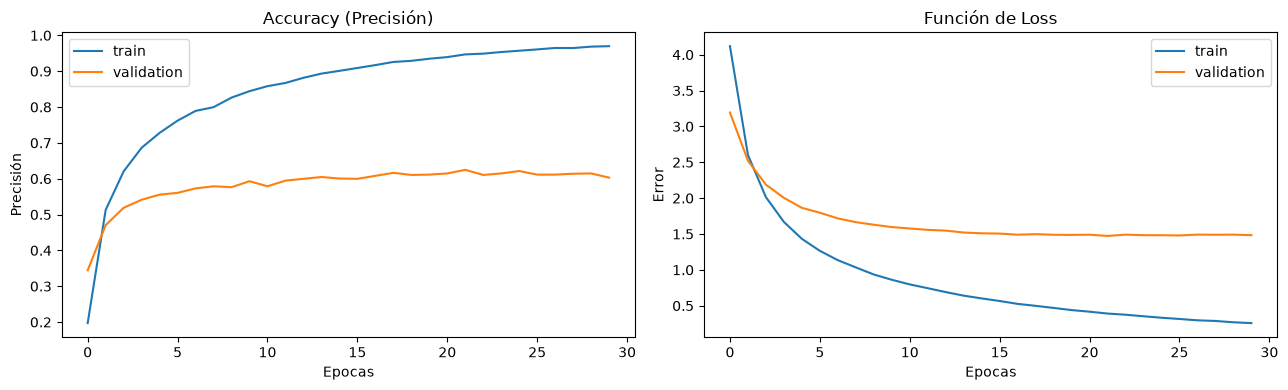

,accuracy,loss,val_accuracy,val_loss
0,0.197080,4.118771,0.344454,3.193227
1,0.512826,2.601428,0.470392,2.521711
2,0.620438,2.013418,0.518766,2.187816
3,0.686340,1.667940,0.541284,2.004059
4,0.727841,1.432195,0.555463,1.864328
5,0.762044,1.264961,0.560467,1.796485
6,0.789155,1.134978,0.572977,1.717334
7,0.799583,1.034054,0.578816,1.664701
8,0.826277,0.935129,0.576314,1.628911
9,0.844213,0.861620,0.592994,1.596285


In [7]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    #ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

history_df = plot_training_history(history)
display(history_df)

## 8. Fine-tuning (fase 2)

Solo se ejecuta si `MODO == "finetuning"`. Partiendo de la cabeza ya entrenada en la fase 1, descongelamos el backbone (`base_model.trainable = True`) y volvemos a congelar las primeras `FINETUNE_FREEZE_LAYERS` capas, dejando entrenables solo las mas altas. Recompilamos con un learning rate bajo (`FINETUNE_LR`) y continuamos con `initial_epoch` para que las epocas sigan la numeracion de la fase 1.

Las capas `BatchNormalization` se mantienen en modo inferencia gracias al `training=False` con que llamamos al `base_model` en la celda del modelo, asi que no hace falta congelarlas una por una.

In [ ]:
print("Numero de capas en el modelo base:", len(base_model.layers))

In [ ]:
if HACER_FINETUNING:
    # Partimos de la base de las celdas del modelo y la fase 1.
    # Descongelamos el modelo base y volvemos a congelar las primeras N capas,
    # dejando entrenables solo las ultimas capas convolucionales.
    base_model.trainable = True
    for layer in base_model.layers[:FINETUNE_FREEZE_LAYERS]:
        layer.trainable = False

    # Recompilamos con un learning rate menor para no desestabilizar el entrenamiento.
    model.compile(
        optimizer=Adam(learning_rate=FINETUNE_LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        initial_epoch=history.epoch[-1] + 1,
        epochs=history.epoch[-1] + 1 + FINETUNE_EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    plot_training_history(history_ft)

## 9. Evaluacion directa en conjunto de prueba

In [8]:
test_metrics = model.evaluate(test_ds, verbose=1)

print("Metricas en conjunto de prueba:")
for name, value in zip(model.metrics_names, test_metrics):
    print(f"{name}: {value:.4f}")


362/363 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.6210 - loss: 1.4342

2026-06-29 20:34:27.097733: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-29 20:34:27.248826: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-29 20:34:27.398562: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


363/363 ━━━━━━━━━━━━━━━━━━━━ 57s 157ms/step - accuracy: 0.6246 - loss: 1.4169
Metricas en conjunto de prueba:
loss: 1.4169
compile_metrics: 0.6246


## 10. Matriz de confusion y reporte de clasificacion


In [9]:
# test_ds no esta barajado; asi y_true y y_pred quedan alineados.
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_pred = model.predict(test_ds, verbose=1).argmax(axis=1)

test_accuracy_from_predictions = np.mean(y_true == y_pred)
print(f"Accuracy en test ({model.name}): {test_accuracy_from_predictions:.4f}")

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).transpose()
display(report_df)


363/363 ━━━━━━━━━━━━━━━━━━━━ 56s 136ms/step
Accuracy en test (Xception_transfer): 0.6246


,precision,recall,f1-score,support
0,0.814815,0.733333,0.771930,30.000000
1,0.862069,0.833333,0.847458,30.000000
2,0.888889,0.857143,0.872727,28.000000
3,0.843750,0.900000,0.870968,30.000000
4,0.611111,0.785714,0.687500,14.000000
...,...,...,...,...
198,0.718750,0.766667,0.741935,30.000000
199,0.657143,0.766667,0.707692,30.000000
accuracy,0.624612,0.624612,0.624612,0.624612
macro avg,0.641782,0.627312,0.624835,5794.000000


In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="viridis")
plt.title(f"Matriz de confusion - {model.name} ({len(class_names)} clases)")
plt.xlabel("Prediccion")
plt.ylabel("Clase real")
plt.colorbar()
plt.tight_layout()
plt.show()

cm_sin_diagonal = cm.copy()
np.fill_diagonal(cm_sin_diagonal, 0)

pares_confundidos = [
    (cm_sin_diagonal[i, j], i, j)
    for i in range(len(cm_sin_diagonal))
    for j in range(len(cm_sin_diagonal))
    if cm_sin_diagonal[i, j] > 0
]
pares_confundidos.sort(reverse=True)

TOP_PARES = 5  # cuantos pares mas confundidos analizamos (print, 10.b y 10.c)
print(f"Top {TOP_PARES} pares mas confundidos:")
for cantidad, real_idx, pred_idx in pares_confundidos[:TOP_PARES]:
    print(f"  '{class_names[real_idx]}' confundida con '{class_names[pred_idx]}': {cantidad} veces")


## 10.b Diccionario indice -> clase

Construimos un diccionario `idx_to_class` que mapea cada entero a su nombre de clase para saber a que especie corresponde cada indice. Esta celda **no depende del modelo entrenado**: usa `class_names` (definido al cargar el dataset) y `pares_confundidos` (de la matriz de confusion), por lo que se puede ejecutar sin volver a correr el entrenamiento.

In [ ]:
# Diccionario indice -> nombre de clase para interpretar los enteros de la matriz de confusion.
# Solo depende de `class_names` y `pares_confundidos`, por lo que se puede correr sin reentrenar.
idx_to_class = dict(enumerate(class_names))

# Nos quedamos con las clases que aparecen en el top de pares mas confundidos.
top_n = TOP_PARES
indices_confundidos = sorted(
    {i for _, real_idx, pred_idx in pares_confundidos[:top_n] for i in (real_idx, pred_idx)}
)
clases_confundidas = {idx: idx_to_class[idx] for idx in indices_confundidos}

print(f"Clases involucradas en el top {top_n} de pares confundidos:")
for idx, nombre in clases_confundidas.items():
    print(f"  {idx}: {nombre}")


## 10.c Imagenes de los pares mas confundidos

Para los `TOP_PARES` pares mas confundidos mostramos ejemplos de la especie **real** (izquierda) y de la especie con la que el modelo la **confunde** (derecha). Asi se ve por que las mezcla: suelen ser visualmente muy parecidas. Las imagenes salen de `ds_test_raw` (sin preprocesar).

In [ ]:
# Recolectamos algunas imagenes de cada especie involucrada en el top de pares.
N_EJEMPLOS = 3  # imagenes por especie

top_pares = pares_confundidos[:TOP_PARES]
clases_necesarias = {idx for _, real_idx, pred_idx in top_pares for idx in (real_idx, pred_idx)}

# Una sola pasada por el test crudo, juntando hasta N_EJEMPLOS imagenes por clase necesaria.
ejemplos = {c: [] for c in clases_necesarias}
for img, lbl in ds_test_raw:  # ds_test_raw = (imagen, etiqueta) sin preprocesar
    c = int(lbl)
    if c in ejemplos and len(ejemplos[c]) < N_EJEMPLOS:
        ejemplos[c].append(img.numpy())
    if all(len(v) >= N_EJEMPLOS for v in ejemplos.values()):
        break

fig, axes = plt.subplots(
    TOP_PARES, 2 * N_EJEMPLOS,
    figsize=(2.2 * 2 * N_EJEMPLOS, 2.4 * TOP_PARES),
)
axes = np.atleast_2d(axes)

for fila, (cantidad, real_idx, pred_idx) in enumerate(top_pares):
    # Especie real (bloque izquierdo).
    for k in range(N_EJEMPLOS):
        ax = axes[fila, k]
        if k < len(ejemplos[real_idx]):
            ax.imshow(ejemplos[real_idx][k])
        ax.axis("off")
        if k == 0:
            ax.set_title(f"REAL: {class_names[real_idx]}", fontsize=8, color="green", loc="left")
    # Especie con la que se confunde (bloque derecho).
    for k in range(N_EJEMPLOS):
        ax = axes[fila, N_EJEMPLOS + k]
        if k < len(ejemplos[pred_idx]):
            ax.imshow(ejemplos[pred_idx][k])
        ax.axis("off")
        if k == 0:
            ax.set_title(f"PRED: {class_names[pred_idx]}  ({cantidad}x)", fontsize=8, color="red", loc="left")

plt.suptitle(f"Top {TOP_PARES} pares mas confundidos: especie real (izq) vs prediccion (der)", fontsize=12)
plt.tight_layout()
plt.show()

## 11. Guardar resultados y modelo


In [11]:
# History completo: fase 1 (+ fase 2 de fine-tuning si corresponde).
frames = [pd.DataFrame(history.history)]
if HACER_FINETUNING:
    frames.append(pd.DataFrame(history_ft.history))
history_full_df = pd.concat(frames, ignore_index=True)

results = {
    "modelo": "Xception",
    "modo": MODO,
    "dataset": DATASET_NAME,
    "train_split": TRAIN_SPLIT,
    "val_split": VAL_SPLIT,
    "test_split": TEST_SPLIT,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "augmentation": USAR_AUGMENTATION,
    "epochs_configuradas": EPOCHS,
    "epochs_ejecutadas": len(history_full_df),
    "learning_rate": LEARNING_RATE,
    "finetune_lr": FINETUNE_LR if HACER_FINETUNING else None,
    "finetune_freeze_layers": FINETUNE_FREEZE_LAYERS if HACER_FINETUNING else None,
    "test_loss": test_metrics[0],
    "test_accuracy": test_metrics[1],
}

results_df = pd.DataFrame([results])
display(results_df)

results_path = RESULTS_DIR / f"xception_{MODO}_results.csv"
history_path = RESULTS_DIR / f"xception_{MODO}_history.csv"
preds_path = RESULTS_DIR / f"xception_{MODO}_preds.csv"
model_path = MODELS_DIR / f"xception_{MODO}.keras"

results_df.to_csv(results_path, index=False)
history_full_df.to_csv(history_path, index=False)
# Predicciones por muestra del test: con esto se regenera la matriz de confusion,
# el reporte por clase y los pares confundidos sin volver a correr el modelo.
pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).to_csv(preds_path, index=False)
model.save(model_path)

# class_names es el mismo para todas las corridas; lo guardamos una sola vez para
# que el notebook de comparacion pueda etiquetar las clases sin cargar tfds.
class_names_path = RESULTS_DIR / "class_names.csv"
if not class_names_path.exists():
    pd.DataFrame({"idx": range(len(class_names)), "clase": class_names}).to_csv(
        class_names_path, index=False
    )

print("Resultados guardados en:", results_path)
print("History guardado en:", history_path)
print("Predicciones guardadas en:", preds_path)
print("Modelo guardado en:", model_path)

,modelo,modo,dataset,train_split,val_split,test_split,img_size,batch_size,augmentation,epochs_configuradas,epochs_ejecutadas,learning_rate,finetune_lr,finetune_freeze_layers,test_loss,test_accuracy
0,Xception,augmentation,caltech_birds2011,train[:80%],train[80%:],test,299,8,True,50,34,0.0005,None,None,1.372689,0.632378


Resultados guardados en: /home/felipe_r/proyectos/TP3-CNN/resultados/xception_augmentation_results.csv
History guardado en: /home/felipe_r/proyectos/TP3-CNN/resultados/xception_augmentation_history.csv
Predicciones guardadas en: /home/felipe_r/proyectos/TP3-CNN/resultados/xception_augmentation_preds.csv
Modelo guardado en: /home/felipe_r/proyectos/TP3-CNN/modelos_guardados/xception_augmentation.keras
